In [1]:
import numpy as np
from sim_library.simulation import simulate_pulses_p_dist, simulate_pulses_single_atom
from sim_library.sequences import gen_resonant_pm_seq, gen_offresonant_pm_seq, UpPulse, DownPulse, FreeEvolution, PulseSequence, gen_MDFE_seq
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, display_table, display_table_compare
from scipy.constants import hbar, pi
from sim_library.constants import k_eff, dR, m, omega_eg
import matplotlib.pyplot as plt

In [2]:
rabi_freq = 2*pi*1e12
rabi_time = 2*pi/rabi_freq

omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 10

### Gates

##### NOT(0)

In [12]:
not_gate = PulseSequence()

freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=omega_time/2) #pi/2
pulse_1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/2) # pi pulse, phase = 0

not_gate.add_pulses([freevolve_1, 
                     pulse_1, 
                     freevolve_1])

##### EX(1,0)

In [45]:
exchange10 = PulseSequence()

freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=5*omega_time/4) #5pi/4
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=omega_time/2) #pi/2
MDFE_1 = gen_MDFE_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=time_steps) #pi/4
pulse_1 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, -pi/4), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #down pi/2 pulse, phase = pi/4
pulse_2 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, -pi), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #down pi/2 pulse, phase = pi

exchange10.add_pulses([freevolve_1, 
                     pulse_1, 
                     MDFE_1, 
                     pulse_2, 
                     freevolve_2])

##### anti CNOT(1,0)

In [46]:
antiCNOT = PulseSequence()

freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=5*omega_time/4) #5pi/4
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=3*omega_time/2) #3pi/2
MDFE_1 = gen_MDFE_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=time_steps) #pi/4
pulse_1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, -pi/4), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #up pi/2 pulse, phase = pi/4
pulse_2 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #up pi/2 pulse, phase = 0
pulse_3 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time) #up 2pi pulse, phase = 0

antiCNOT.add_pulses([freevolve_1, 
                     pulse_1, 
                     MDFE_1, 
                     pulse_2, 
                     freevolve_2, 
                     pulse_3])

##### SW3(2,3)

In [47]:
swap23 = PulseSequence()

MDFE_1 = gen_MDFE_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=time_steps) #pi/4
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=13*omega_time/8) #13pi/8
pulse_1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 9*pi/8), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #up pi/2 pulse, phase = 9pi/8
MDFE_2 = gen_MDFE_seq(free_time=pi/(8*dR), rabi_freq=rabi_freq, time_steps=time_steps) #pi/8
pulse_2 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #up pi/2 pulse, phase = 0
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=5*omega_time/4) #5pi/4

swap23.add_pulses([MDFE_1,
                   freevolve_1,
                   pulse_1,
                   MDFE_2,
                   pulse_2,
                   MDFE_2,
                   freevolve_2,
                   pulse_1,
                   MDFE_2,
                   pulse_2])

##### SW3(3,4)

In [48]:
swap34 = PulseSequence()

MDFE_1 = gen_MDFE_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=time_steps) #pi/4
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=13*omega_time/8) #13pi/8
pulse_1 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 5*pi/8), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #down pi/2 pulse, phase = 5pi/8
MDFE_2 = gen_MDFE_seq(free_time=pi/(8*dR), rabi_freq=rabi_freq, time_steps=time_steps) #pi/8
pulse_2 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #down pi/2 pulse, phase = 0
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=5*omega_time/4) #5pi/4
freevolve_3 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=omega_time) #pi

swap34.add_pulses([MDFE_1,
                   freevolve_1,
                   pulse_1,
                   MDFE_2,
                   pulse_2,
                   MDFE_2,
                   freevolve_2,
                   pulse_1,
                   MDFE_2,
                   pulse_2,
                   freevolve_3])

##### SW3(4,5)

In [49]:
swap45 = PulseSequence()

MDFE_1 = gen_MDFE_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=time_steps) #pi/4
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=omega_time/8) #pi/8
pulse_1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 5*pi/8), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #up pi/2 pulse, phase = 5pi/8
MDFE_2 = gen_MDFE_seq(free_time=pi/(8*dR), rabi_freq=rabi_freq, time_steps=time_steps) #pi/8
pulse_2 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #up pi/2 pulse, phase = 0
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=5*omega_time/4) #5pi/4

swap45.add_pulses([MDFE_1,
                   freevolve_1,
                   pulse_1,
                   MDFE_2,
                   pulse_2,
                   MDFE_2,
                   freevolve_2,
                   pulse_1,
                   MDFE_2,
                   pulse_2])


##### EX(2,1)

In [50]:
exchange21 = PulseSequence()

freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=5*omega_time/8) #5pi/8
MDFE_1 = gen_MDFE_seq(free_time=3*pi/(8*dR), rabi_freq=rabi_freq, time_steps=time_steps) #3pi/8
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=omega_time) #pi
freevolve_3 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=13*omega_time/8) #13pi/8
pulse_1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time) #up 2pi pulse, phase = 0

exchange21.add_pulses([freevolve_1,
                       MDFE_1,
                       swap34,
                       swap23,
                       not_gate,
                       freevolve_2,
                       not_gate,
                       swap45,
                       not_gate,
                       freevolve_2,
                       not_gate,
                       swap34,
                       antiCNOT,
                       exchange10,
                       freevolve_3,
                       MDFE_1,
                       exchange10,
                       antiCNOT,
                       pulse_1])

#### Tommys gates

##### Ramsey gate

In [18]:
ramsey = PulseSequence()

pulse_1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi/2), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #up pi/2 pulse, phase = pi/2
MDFE_1 = gen_MDFE_seq(free_time=pi/(8*dR), rabi_freq=rabi_freq, time_steps=time_steps) 
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=3*omega_time/8) 
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=omega_time) 

ramsey.add_pulses([pulse_1,
                   freevolve_1,
                   MDFE_1,
                   pulse_1,
                   ])


##### SW3(0,1)

In [19]:
swap01 = PulseSequence()

MDFE_1 = gen_MDFE_seq(free_time=pi/(8*dR), rabi_freq=rabi_freq, time_steps=time_steps) 
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=7*omega_time/8) 

swap01.add_pulses([ramsey,
                   freevolve_1,
                   MDFE_1,
                   ramsey])



##### SW3(4,5)v2

In [20]:
swap45v2 = PulseSequence()

MDFE_1 = gen_MDFE_seq(free_time=pi/(8*dR), rabi_freq=rabi_freq, time_steps=time_steps) 
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=15*omega_time/8) 

swap45v2.add_pulses([ramsey,
                   freevolve_1,
                   MDFE_1,
                   ramsey,
                   ])

##### SW3(4,5)v2.1

In [21]:
# This is the same as above with some phase correction

swap45v2_1 = PulseSequence()

MDFE_1 = gen_MDFE_seq(free_time=pi/(8*dR), rabi_freq=rabi_freq, time_steps=time_steps) 
MDFE_2 = gen_MDFE_seq(free_time=3*pi/(8*dR), rabi_freq=rabi_freq, time_steps=time_steps) 
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=15*omega_time/8) 
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=13*omega_time/8) 

swap45v2_1.add_pulses([ramsey,
                   freevolve_1,
                   MDFE_1,
                   ramsey,
                   freevolve_2,
                   MDFE_2])

##### EX(1,0)v2

In [22]:
exchange10v2 = PulseSequence()

pulse_1 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi/2), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #up pi/2 pulse, phase = pi/2

MDFE_1 = gen_MDFE_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=time_steps) 
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, +omega_eg/2)), duration=5*omega_time/4) 
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, +omega_eg/2)), duration=omega_time)



exchange10v2.add_pulses([pulse_1,
                   freevolve_1,
                   MDFE_1,
                   pulse_1,
                   freevolve_2])


##### antiCNOT(1,0)v2

In [23]:
antiCNOTv2 = PulseSequence()

pulse_1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi/2), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #up pi/2 pulse, phase = pi/2
pulse_2 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time) 
MDFE_1 = gen_MDFE_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=time_steps) 
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=7*omega_time/4) 
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=omega_time)


antiCNOTv2.add_pulses([pulse_1,
                   freevolve_1,
                   MDFE_1,
                   pulse_1,
                   freevolve_2,
                   ])

##### SW3(2,3)v2

In [24]:
swap23v2 = PulseSequence()

pulse_1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi/2), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #up pi/2 pulse, phase = pi/2
MDFE_1 = gen_MDFE_seq(free_time=pi/(8*dR), rabi_freq=rabi_freq, time_steps=time_steps) 
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=7*omega_time/8) 
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=3*omega_time/8) 

swap23v2.add_pulses([pulse_1,
                     freevolve_1,
                     MDFE_1,
                     pulse_1,
                     freevolve_2,
                     MDFE_1,
                     pulse_1,
                     freevolve_1,
                     MDFE_1,
                     pulse_1
                     ])


##### SW3(3,4)v2

In [25]:
swap34v2 = PulseSequence()

pulse_1 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, pi/2), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4)
MDFE_1 = gen_MDFE_seq(free_time=pi/(8*dR), rabi_freq=rabi_freq, time_steps=time_steps) 
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, +omega_eg/2)), duration=5*omega_time/8) 
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, +omega_eg/2)), duration=omega_time/8) 

swap34v2.add_pulses([pulse_1,
                     freevolve_1,
                     MDFE_1,
                     pulse_1,
                     freevolve_2,
                     MDFE_1,
                     pulse_1,
                     freevolve_1,
                     MDFE_1,
                     pulse_1,

                    ])

##### EX(2,1)v2

In [44]:
exchange21v2 = PulseSequence()

freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=5*omega_time/8) #5pi/8
MDFE_1 = gen_MDFE_seq(free_time=3*pi/(8*dR), rabi_freq=rabi_freq, time_steps=time_steps) #3pi/8
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=omega_time) #pi
freevolve_3 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=13*omega_time/8) #13pi/8
pulse_1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time) #up 2pi pulse, phase = 0

exchange21v2.add_pulses([
                       swap34v2,
                       swap23v2,
                     #   not_gate,
                     #   freevolve_2,
                     #   not_gate,
                       swap45v2,
                    #    not_gate,
                    #    freevolve_2,
                    #    not_gate,
                       swap34v2,
                      #  antiCNOTv2,
                      #  exchange10v2,
                      #  freevolve_3,
                      #  MDFE_1,
                      #  exchange10v2,
                      #  antiCNOTv2,
                       ])

### RR3 sim

In [60]:
test_gate = PulseSequence()

freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -omega_eg/2)), duration=omega_time) 
pulse1 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time) #up 2pi pulse, phase = 0 

test_gate.add_pulses([
                    # not_gate,
                    freevolve_1,
                    # not_gate,
                    pulse_1,
                    ])

In [45]:
RR3 = PulseSequence()

RR3.add_pulses([exchange10v2, exchange21v2])

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
# initial_state[15] = 1
initial_state[16] = 1
initial_state[17] = 0
initial_state[18] = -2
initial_state[19] = 0
initial_state[20] = 3j
initial_state[21] = 0
initial_state[22] = -4j                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 
initial_state[23] = 0
# initial_state[24] = 0

initial_state = initial_state/ np.linalg.norm(initial_state)

wave_func, times = simulate_pulses_single_atom(pulse_seq= RR3, basis= basis, initial_state=initial_state, d_shift=0)

display_table_compare(basis=basis, init_state=initial_state, final_state=wave_func[-1,:])

# # fig, ax = plt.subplots()
# probs = np.abs(wave_func)**2
# # plot_state_trajectories(ax=ax, wavefunc=probs, time_array=times, basis=basis)




+---------+---------------------+------------------+---------------------+-------------------+-----------------+
|   Index |   Momentum (hbar*k) |      Initial Psi |           Final Psi |   Initial |Psi|^2 |   Final |Psi|^2 |
+=========+=====================+==================+=====================+===================+=================+
|       0 |                 -16 |          0j|000> |        (-0-0j)|000> |             0     |           0     |
+---------+---------------------+------------------+---------------------+-------------------+-----------------+
|       1 |                 -15 |          0j|001> |        (-0-0j)|001> |             0     |           0     |
+---------+---------------------+------------------+---------------------+-------------------+-----------------+
|       2 |                 -14 |          0j|010> |        (-0-0j)|010> |             0     |           0     |
+---------+---------------------+------------------+---------------------+-------------------+--

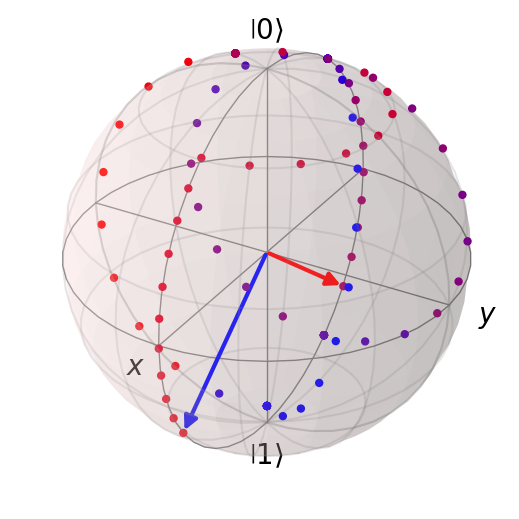

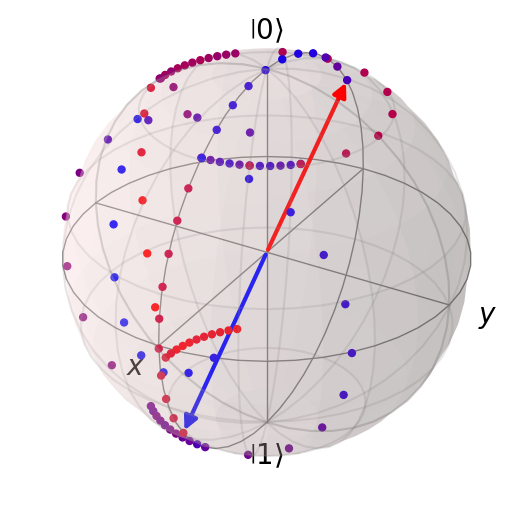

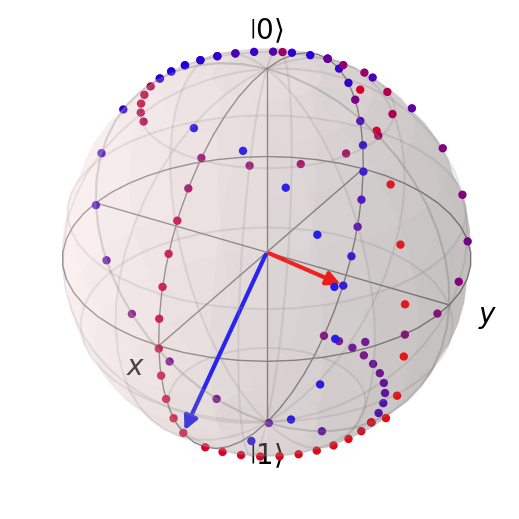

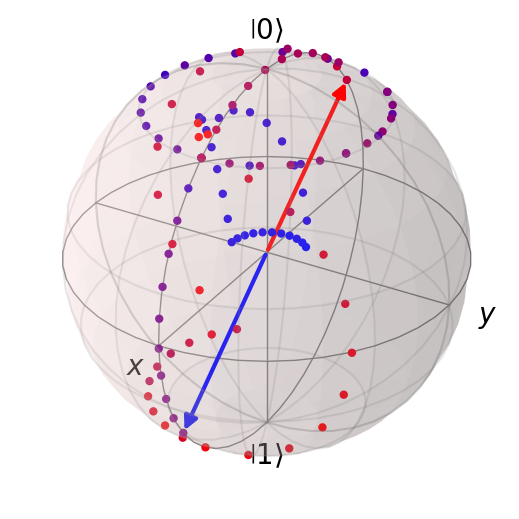

In [215]:
pair01 = wave_func[:,15:17]
pair01 = pair01/np.linalg.norm(pair01[0])
pair23 = wave_func[:,17:19]
pair23 = pair23/np.linalg.norm(pair23[0])
pair45 = wave_func[:,19:21]
pair45 = pair45/np.linalg.norm(pair45[0])
pair67 = wave_func[:,21:23]
pair67 = pair67/np.linalg.norm(pair67[0])

plot_bloch(pair01)
plot_bloch(pair23)
plot_bloch(pair45)
plot_bloch(pair67)


[0 1 2 3 4 5 6]
